In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [68]:
# load and view the dataset
netflix_df = pd.read_csv('netflix_user_behavior_dataset.csv')
netflix_df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [69]:
# check shape of dataframe
print(f"Rows: {netflix_df.shape[0]}\nColumns: {netflix_df.shape[1]}")

Rows: 50000
Columns: 20


In [70]:
# check for null values
netflix_df.isnull().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

There are no missing values in this dataset because it is synthetic. So, there is no need to drop rows or impute values to handle null values.

In [71]:
# coerce values into create types
# user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
netflix_df['user_id'] = netflix_df['user_id'].astype(str)
netflix_df['age'] = netflix_df['age'].astype(int)
netflix_df['gender'] = netflix_df['gender'].astype('category')
netflix_df['country'] = netflix_df['country'].astype('category')
netflix_df['account_age_months'] = netflix_df['account_age_months'].astype(int)
netflix_df['subscription_type'] = netflix_df['subscription_type'].astype('category')
netflix_df['monthly_fee'] = netflix_df['monthly_fee'].astype(float)
netflix_df['payment_method'] = netflix_df['payment_method'].astype('category')
netflix_df['primary_device'] = netflix_df['primary_device'].astype('category')
netflix_df['devices_used'] = netflix_df['devices_used'].astype(int)
netflix_df['favorite_genre'] = netflix_df['favorite_genre'].astype('category')
netflix_df['avg_watch_time_minutes'] = netflix_df['avg_watch_time_minutes'].astype(int)
netflix_df['watch_sessions_per_week'] = netflix_df['watch_sessions_per_week'].astype(int)
netflix_df['binge_watch_sessions'] = netflix_df['binge_watch_sessions'].astype(int)
netflix_df['completion_rate'] = netflix_df['completion_rate'].astype(int)
netflix_df['rating_given'] = netflix_df['rating_given'].astype(float)
netflix_df['content_interactions'] = netflix_df['content_interactions'].astype(int)
netflix_df['recommendation_click_rate'] = netflix_df['recommendation_click_rate'].astype(int)
netflix_df['days_since_last_login'] = netflix_df['days_since_last_login'].astype(int)
# map churn No to False and Yes to True as bool
churn_map = {'No': False, 'Yes': True}
netflix_df['churned'] = netflix_df['churned'].map(churn_map).astype(bool)

netflix_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   user_id                    50000 non-null  str     
 1   age                        50000 non-null  int64   
 2   gender                     50000 non-null  category
 3   country                    50000 non-null  category
 4   account_age_months         50000 non-null  int64   
 5   subscription_type          50000 non-null  category
 6   monthly_fee                50000 non-null  float64 
 7   payment_method             50000 non-null  category
 8   primary_device             50000 non-null  category
 9   devices_used               50000 non-null  int64   
 10  favorite_genre             50000 non-null  category
 11  avg_watch_time_minutes     50000 non-null  int64   
 12  watch_sessions_per_week    50000 non-null  int64   
 13  binge_watch_sessions       50000 non-null 

In [72]:
# get summary statistics for numeric columns
numerical_cols = netflix_df.select_dtypes(include=['int64', 'float64']).columns
netflix_df[numerical_cols].describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


In [73]:
# get summary statistics for categorical columns
categorical_cols = netflix_df.select_dtypes(include=['category']).columns

for col in categorical_cols:
    print(f"{col[0].upper()}{col[1:]} value counts:\n{netflix_df[col].value_counts()}")
    print(f"Unique values: {netflix_df[col].unique()}")
    print(f"Mode: {netflix_df[col].mode()[0]}\n")

Gender value counts:
gender
Female    16759
Male      16737
Other     16504
Name: count, dtype: int64
Unique values: ['Male', 'Female', 'Other']
Categories (3, str): ['Female', 'Male', 'Other']
Mode: Female

Country value counts:
country
Brazil       5116
USA          5087
India        5028
Spain        5027
Germany      5024
Australia    5004
Canada       4959
UK           4929
France       4919
Japan        4907
Name: count, dtype: int64
Unique values: ['India', 'USA', 'Canada', 'Brazil', 'France', 'Australia', 'UK', 'Japan', 'Germany', 'Spain']
Categories (10, str): ['Australia', 'Brazil', 'Canada', 'France', ..., 'Japan', 'Spain', 'UK', 'USA']
Mode: Brazil

Subscription_type value counts:
subscription_type
Standard    19931
Premium     15196
Basic       14873
Name: count, dtype: int64
Unique values: ['Standard', 'Basic', 'Premium']
Categories (3, str): ['Basic', 'Premium', 'Standard']
Mode: Standard

Payment_method value counts:
payment_method
PayPal         12539
Credit Card    12

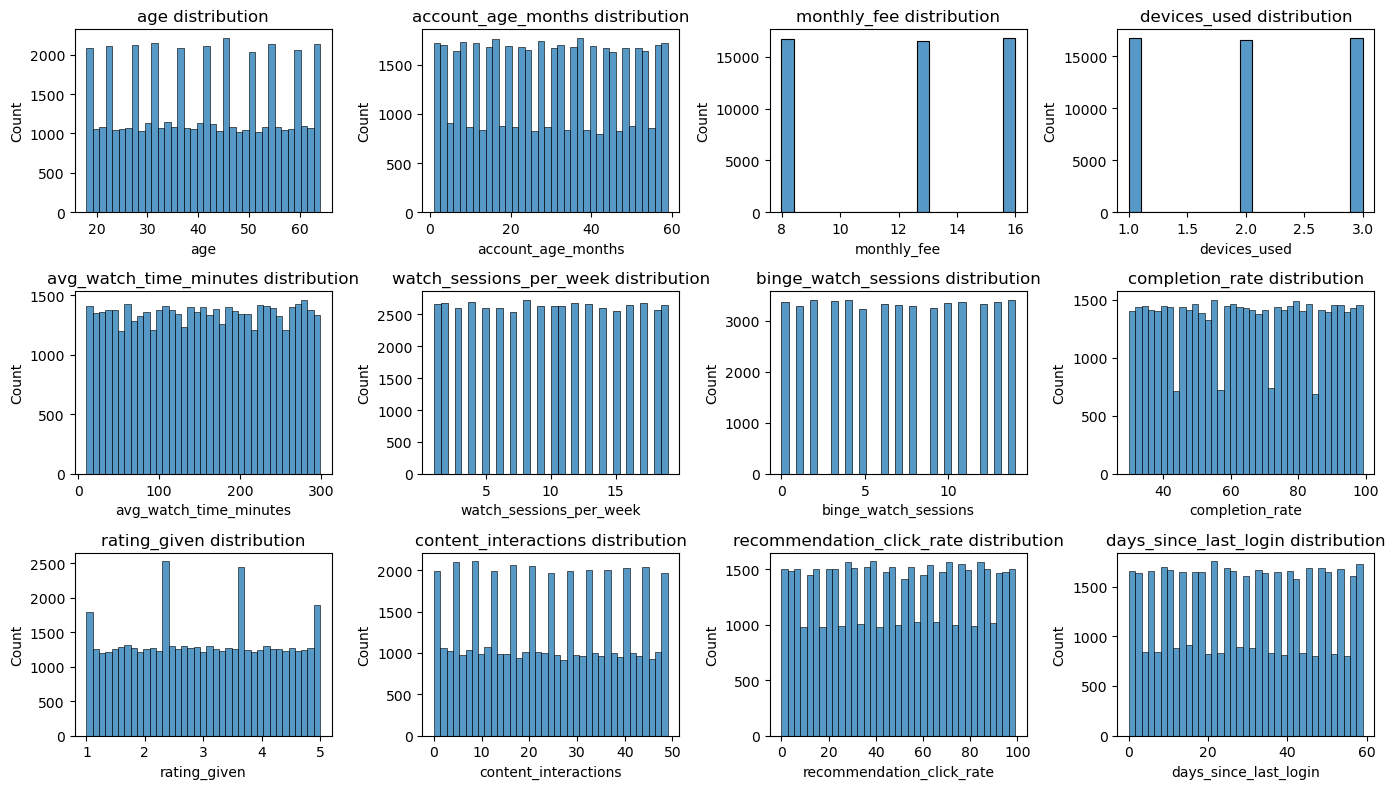

In [74]:
# histograms for numeric columns using subplots as 4x3 grid
# reference for subplots: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html
plt.figure(figsize=(14, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(netflix_df[col])
    plt.title(f"{col} distribution")
plt.tight_layout()
plt.show()

These distributions show that some numeric columns could actually be categorical if we wanted to. For example, monthly_fee and devices_used only have a few unique values, so they could be converted to categorical columns instead. The rest of the distributions seem to be symmetric with minimal or no skew. This is likely a result of the synthetic nature of the dataset we chose.

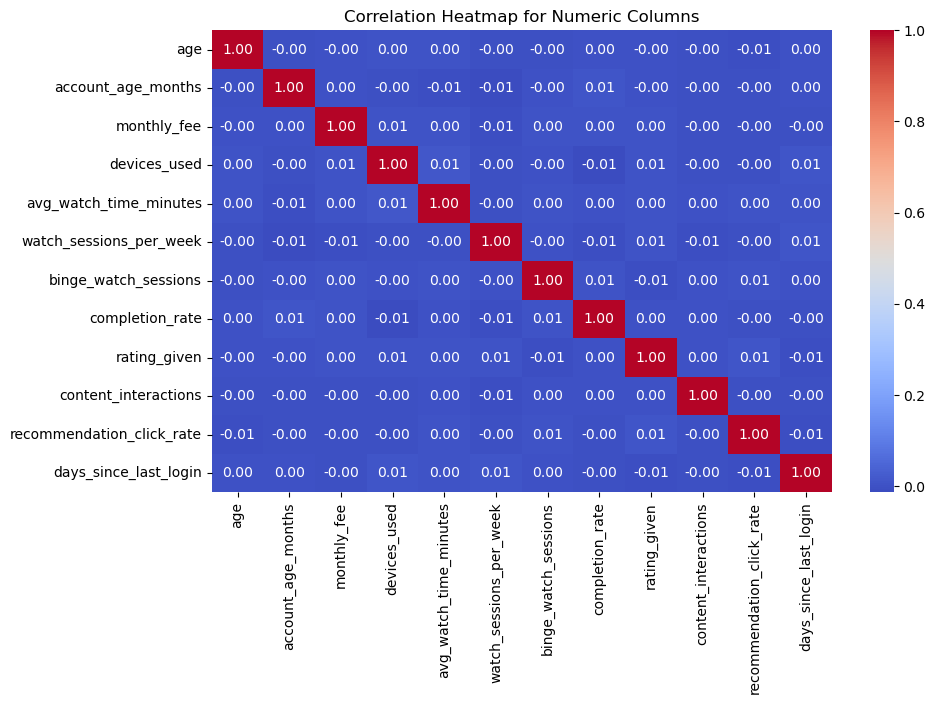

In [75]:
# plot a correlation heatmap for numeric columns
# reference: https://seaborn.pydata.org/generated/seaborn.heatmap.html
plt.figure(figsize=(10, 6))
correlation_matrix = netflix_df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap for Numeric Columns")
plt.show()

Almost no relationships between numeric columns, this may lead to difficulties modelling.

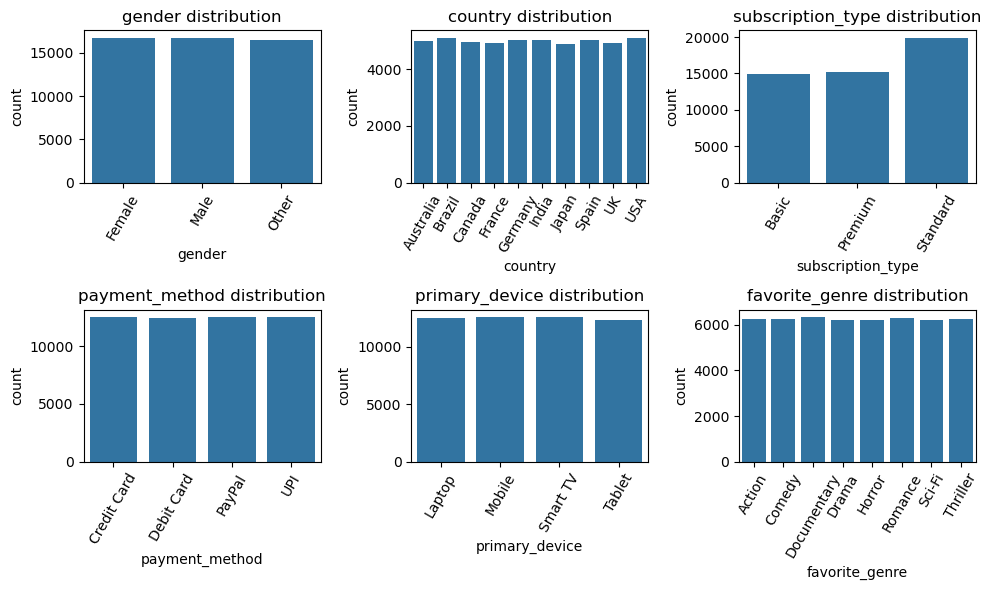

In [76]:
# plot categorical variables as countplots
plt.figure(figsize=(10, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=netflix_df[col])
    plt.title(f"{col} distribution")
    plt.xticks(rotation=60) # rotate so they aren't overlapping
plt.tight_layout()
plt.show()

Very even distribution again for the categorical columns. It's likely that models will have trouble reaching high accuracy because of this distribution.

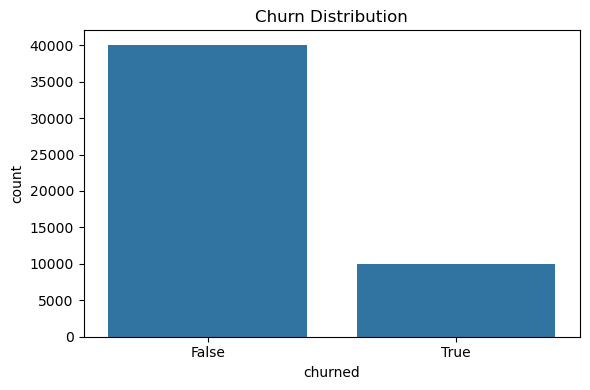

In [79]:
# plot churn as countplot
plt.figure(figsize=(6, 4))
sns.countplot(x=netflix_df['churned'])
plt.title("Churn Distribution")
plt.tight_layout()
plt.show()

There are far more false churns than true churns. This means (based on synthetic data) that Netflix has a very high customer retention rate.